# Miniproyecto 4

En este Jupyter Notebook pueden implementar los códigos necesarios para resolver el **Miniproyecto 4**.

**Importante:** Recuerden que, como grupo, deben **adjuntar el código** en su entrega.

Tengan en cuenta que Coursera utiliza recursos compartidos entre todos los grupos, por lo tanto, si hay muchos equipos trabajando al mismo tiempo, los procesos pueden demorar más de lo previsto.

Pueden agregar todas las celdas de código que consideren necesarias para resolver el miniproyecto. **No hay un límite en este aspecto.**

In [3]:
# Espacio para desarrollar el código del miniproyecto 4

# Instalar las bibliotecas necesarias
import sys
import subprocess

packages = ['torch', 'torchaudio', 'transformers', 'datasets', 'scikit-learn', 'numpy', 'matplotlib', 'seaborn', 'pandas', 'tf-keras', 'librosa', 'soundfile']

for package in packages:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', package, '-q'])

In [4]:
import torch
import torch.nn as nn
import torchaudio
from datasets import load_dataset
from transformers import ASTFeatureExtractor, ASTForAudioClassification, TrainingArguments, Trainer
import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Dict
import warnings
warnings.filterwarnings('ignore')

# Verificar disponibilidad de GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")

Usando dispositivo: cuda


In [6]:
# Dataset de entrenamiento
dataset = load_dataset("confit/esc50-demo", "fold1", split="train")

# Dataset de test
val_dataset = load_dataset("confit/esc50-demo", "fold1", split="test")

print(f"Dataset de entrenamiento: {len(dataset)} muestras")
print(f"Dataset de validación: {len(val_dataset)} muestras")
print(f"\nColumnas del dataset: {dataset.column_names}")
print(f"Features: {dataset.features}")

Dataset de entrenamiento: 1600 muestras
Dataset de validación: 400 muestras

Columnas del dataset: ['audio', 'sound', 'label']
Features: {'audio': Audio(sampling_rate=44100, mono=True, decode=True, id=None), 'sound': Value(dtype='string', id=None), 'label': ClassLabel(names=['airplane', 'breathing', 'brushing_teeth', 'can_opening', 'car_horn', 'cat', 'chainsaw', 'chirping_birds', 'church_bells', 'clapping', 'clock_alarm', 'clock_tick', 'coughing', 'cow', 'crackling_fire', 'crickets', 'crow', 'crying_baby', 'dog', 'door_wood_creaks', 'door_wood_knock', 'drinking_sipping', 'engine', 'fireworks', 'footsteps', 'frog', 'glass_breaking', 'hand_saw', 'helicopter', 'hen', 'insects', 'keyboard_typing', 'laughing', 'mouse_click', 'pig', 'pouring_water', 'rain', 'rooster', 'sea_waves', 'sheep', 'siren', 'sneezing', 'snoring', 'thunderstorm', 'toilet_flush', 'train', 'vacuum_cleaner', 'washing_machine', 'water_drops', 'wind'], id=None)}


In [7]:
# Obtener las etiquetas únicas
labels = dataset.features['label'].names
print(f"Número de categorías: {len(labels)}")
print(f"Categorías: {labels}")

# Crear mapeo de etiquetas
label2id = {label: i for i, label in enumerate(labels)}
id2label = {i: label for i, label in enumerate(labels)}

print(f"\nMapeo de etiquetas: {label2id}")

Número de categorías: 50
Categorías: ['airplane', 'breathing', 'brushing_teeth', 'can_opening', 'car_horn', 'cat', 'chainsaw', 'chirping_birds', 'church_bells', 'clapping', 'clock_alarm', 'clock_tick', 'coughing', 'cow', 'crackling_fire', 'crickets', 'crow', 'crying_baby', 'dog', 'door_wood_creaks', 'door_wood_knock', 'drinking_sipping', 'engine', 'fireworks', 'footsteps', 'frog', 'glass_breaking', 'hand_saw', 'helicopter', 'hen', 'insects', 'keyboard_typing', 'laughing', 'mouse_click', 'pig', 'pouring_water', 'rain', 'rooster', 'sea_waves', 'sheep', 'siren', 'sneezing', 'snoring', 'thunderstorm', 'toilet_flush', 'train', 'vacuum_cleaner', 'washing_machine', 'water_drops', 'wind']

Mapeo de etiquetas: {'airplane': 0, 'breathing': 1, 'brushing_teeth': 2, 'can_opening': 3, 'car_horn': 4, 'cat': 5, 'chainsaw': 6, 'chirping_birds': 7, 'church_bells': 8, 'clapping': 9, 'clock_alarm': 10, 'clock_tick': 11, 'coughing': 12, 'cow': 13, 'crackling_fire': 14, 'crickets': 15, 'crow': 16, 'crying_b

In [8]:
# Cargar el feature extractor del modelo preentrenado
model_name = "MIT/ast-finetuned-audioset-10-10-0.4593"
feature_extractor = ASTFeatureExtractor.from_pretrained(model_name)

print(f"Feature extractor cargado desde: {model_name}")
print(f"Sampling rate esperado: {feature_extractor.sampling_rate} Hz")
print(f"Tamaño máximo de entrada: {feature_extractor.max_length}")

preprocessor_config.json:   0%|          | 0.00/297 [00:00<?, ?B/s]

Feature extractor cargado desde: MIT/ast-finetuned-audioset-10-10-0.4593
Sampling rate esperado: 16000 Hz
Tamaño máximo de entrada: 1024


In [9]:
import soundfile as sf
import os

def preprocess_audio(batch):
    """
    Procesa el audio convirtiéndolo en espectrogramas.
    - Normaliza los datos
    - Garantiza consistencia en los tamaños de entrada
    - Prepara las entradas para el modelo AST
    """
    # Obtener el audio - cuando decode=False, batch['audio'] es un dict con 'path' y 'bytes'
    audio_info = batch['audio']
    
    # Si tenemos bytes, cargar desde bytes, sino desde path
    if 'bytes' in audio_info and audio_info['bytes'] is not None:
        import io
        audio, sampling_rate = sf.read(io.BytesIO(audio_info['bytes']))
    elif 'path' in audio_info:
        # Usar el path directamente
        audio, sampling_rate = sf.read(audio_info['path'])
    else:
        raise ValueError(f"No se puede cargar el audio: {audio_info}")
    
    # Convertir a numpy array si no lo es
    audio = np.array(audio, dtype=np.float32)
    
    # Si es estéreo, convertir a mono
    if len(audio.shape) > 1:
        audio = np.mean(audio, axis=1)
    
    # Resamplear si es necesario
    if sampling_rate != feature_extractor.sampling_rate:
        resampler = torchaudio.transforms.Resample(
            orig_freq=sampling_rate,
            new_freq=feature_extractor.sampling_rate
        )
        audio = resampler(torch.tensor(audio)).numpy()
    
    # Extraer características (espectrogramas)
    inputs = feature_extractor(
        audio,
        sampling_rate=feature_extractor.sampling_rate,
        return_tensors="pt",
        max_length=feature_extractor.max_length,
        padding="max_length",
        truncation=True
    )
    
    batch['input_values'] = inputs['input_values'][0]
    batch['labels'] = batch['label']
    
    return batch

print("Función de preprocesamiento creada")

Función de preprocesamiento creada


In [10]:
# Aplicar el preprocesamiento a los datasets
# Deshabilitar la decodificación automática de audio
from datasets import Audio as AudioFeature

print("Procesando dataset de entrenamiento...")
dataset = dataset.cast_column("audio", AudioFeature(decode=False))
dataset = dataset.map(preprocess_audio, remove_columns=['audio'])

print("Procesando dataset de validación...")
val_dataset = val_dataset.cast_column("audio", AudioFeature(decode=False))
val_dataset = val_dataset.map(preprocess_audio, remove_columns=['audio'])

print("\nProcesamiento completado!")
print(f"Columnas del dataset procesado: {dataset.column_names}")

Procesando dataset de entrenamiento...


Map:   0%|          | 0/1600 [00:00<?, ? examples/s]

Procesando dataset de validación...


Map:   0%|          | 0/400 [00:00<?, ? examples/s]


Procesamiento completado!
Columnas del dataset procesado: ['sound', 'label', 'input_values', 'labels']


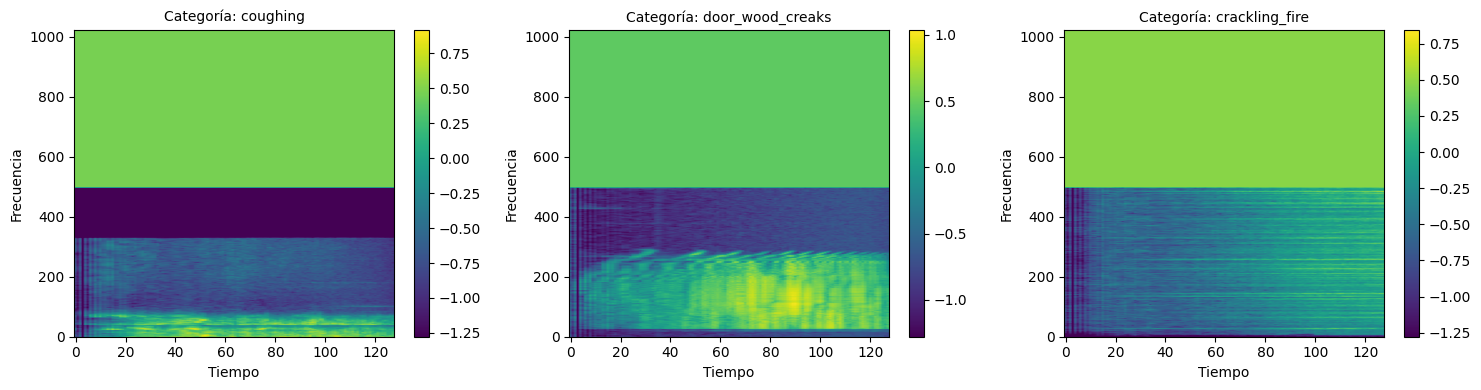

Espectrogramas visualizados y guardados como 'espectrogramas_ejemplo.png'


In [11]:
# Visualizar algunos espectrogramas de ejemplo
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx in range(3):
    if idx < len(dataset):
        spectrogram = np.array(dataset[idx]['input_values'])
        label = id2label[dataset[idx]['labels']]
        
        im = axes[idx].imshow(spectrogram, aspect='auto', origin='lower', cmap='viridis')
        axes[idx].set_title(f'Categoría: {label}', fontsize=10)
        axes[idx].set_xlabel('Tiempo')
        axes[idx].set_ylabel('Frecuencia')
        plt.colorbar(im, ax=axes[idx])

plt.tight_layout()
plt.savefig('espectrogramas_ejemplo.png', dpi=150, bbox_inches='tight')
plt.show()

print("Espectrogramas visualizados y guardados como 'espectrogramas_ejemplo.png'")

In [12]:
# Cargar el modelo preentrenado AST
num_labels = len(labels)

model = ASTForAudioClassification.from_pretrained(
    model_name,
    num_labels=num_labels,
    label2id=label2id,
    id2label=id2label,
    ignore_mismatched_sizes=True
)

model.to(device)

print(f"Modelo cargado: {model_name}")
print(f"Número de parámetros: {sum(p.numel() for p in model.parameters()):,}")
print(f"Número de parámetros entrenables: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Some weights of ASTForAudioClassification were not initialized from the model checkpoint at MIT/ast-finetuned-audioset-10-10-0.4593 and are newly initialized because the shapes did not match:
- classifier.dense.bias: found shape torch.Size([527]) in the checkpoint and torch.Size([50]) in the model instantiated
- classifier.dense.weight: found shape torch.Size([527, 768]) in the checkpoint and torch.Size([50, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Modelo cargado: MIT/ast-finetuned-audioset-10-10-0.4593
Número de parámetros: 86,227,250
Número de parámetros entrenables: 86,227,250


In [13]:
def compute_metrics(eval_pred):
    """
    Calcula métricas de evaluación: accuracy, precision, recall y F1-score
    """
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    
    # Calcular accuracy
    accuracy = accuracy_score(labels, predictions)
    
    # Calcular precision, recall y F1-score
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, predictions, average='weighted', zero_division=0
    )
    
    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1
    }

print("Función de métricas definida")

Función de métricas definida


In [15]:
# Definir argumentos de entrenamiento para 2 épocas
training_args = TrainingArguments(
    output_dir="./ast_finetuned_esc50",
    evaluation_strategy="epoch",
    save_strategy="epoch",
    learning_rate=5e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=2,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    push_to_hub=False,
    logging_dir='./logs',
    logging_steps=10,
    warmup_ratio=0.1,
    save_total_limit=2,
)

print("Argumentos de entrenamiento configurados:")
print(f"- Épocas: {training_args.num_train_epochs}")
print(f"- Learning rate: {training_args.learning_rate}")
print(f"- Batch size (train): {training_args.per_device_train_batch_size}")
print(f"- Batch size (eval): {training_args.per_device_eval_batch_size}")

Argumentos de entrenamiento configurados:
- Épocas: 2
- Learning rate: 5e-05
- Batch size (train): 8
- Batch size (eval): 8


In [16]:
# Crear el Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
)

print("Trainer creado y listo para entrenamiento")

Trainer creado y listo para entrenamiento


In [17]:
# Entrenar el modelo
print("Iniciando fine-tuning del modelo...\n")
train_result = trainer.train()

print("\n=== Entrenamiento Completado ===")
print(f"Tiempo total: {train_result.metrics['train_runtime']:.2f} segundos")
print(f"Loss final: {train_result.metrics['train_loss']:.4f}")

Iniciando fine-tuning del modelo...



Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.211400,0.423147,0.887500,0.911160,0.887500,0.881088
2,0.089900,0.277575,0.932500,0.938442,0.932500,0.930062


Some non-default generation parameters are set in the model config. These should go into a GenerationConfig file (https://huggingface.co/docs/transformers/generation_strategies#save-a-custom-decoding-strategy-with-your-model) instead. This warning will be raised to an exception in v4.41.
Non-default generation parameters: {'max_length': 1024}
Some non-default generation parameters are set in the model config. These should go into a GenerationConfig file (https://huggingface.co/docs/transformers/generation_strategies#save-a-custom-decoding-strategy-with-your-model) instead. This warning will be raised to an exception in v4.41.
Non-default generation parameters: {'max_length': 1024}



=== Entrenamiento Completado ===
Tiempo total: 589.95 segundos
Loss final: 0.5867


In [18]:
# Guardar el modelo fine-tuned
trainer.save_model("./ast_finetuned_final")
feature_extractor.save_pretrained("./ast_finetuned_final")

print("Modelo guardado en: ./ast_finetuned_final")

Some non-default generation parameters are set in the model config. These should go into a GenerationConfig file (https://huggingface.co/docs/transformers/generation_strategies#save-a-custom-decoding-strategy-with-your-model) instead. This warning will be raised to an exception in v4.41.
Non-default generation parameters: {'max_length': 1024}


Modelo guardado en: ./ast_finetuned_final


In [19]:
# Evaluar el modelo en el conjunto de validación
print("Evaluando el modelo...\n")
eval_results = trainer.evaluate()

print("=== Métricas de Evaluación ===")
print(f"Accuracy: {eval_results['eval_accuracy']:.4f}")
print(f"Precision: {eval_results['eval_precision']:.4f}")
print(f"Recall: {eval_results['eval_recall']:.4f}")
print(f"F1-Score: {eval_results['eval_f1']:.4f}")

Evaluando el modelo...



=== Métricas de Evaluación ===
Accuracy: 0.9325
Precision: 0.9384
Recall: 0.9325
F1-Score: 0.9301


In [20]:
# Realizar predicciones en el conjunto de validación
predictions = trainer.predict(val_dataset)
pred_labels = np.argmax(predictions.predictions, axis=1)
true_labels = predictions.label_ids

print("Predicciones realizadas")
print(f"Total de muestras evaluadas: {len(pred_labels)}")

Predicciones realizadas
Total de muestras evaluadas: 400


In [21]:
# Generar reporte de clasificación detallado
target_names = [id2label[i] for i in range(len(labels))]
report = classification_report(
    true_labels,
    pred_labels,
    target_names=target_names,
    zero_division=0
)

print("=== Reporte de Clasificación por Categoría ===")
print(report)

# Guardar el reporte
with open('classification_report.txt', 'w', encoding='utf-8') as f:
    f.write("=== Reporte de Clasificación por Categoría ===\n")
    f.write(report)

print("\nReporte guardado en: classification_report.txt")

=== Reporte de Clasificación por Categoría ===
                  precision    recall  f1-score   support

        airplane       1.00      1.00      1.00         8
       breathing       0.86      0.75      0.80         8
  brushing_teeth       1.00      1.00      1.00         8
     can_opening       1.00      1.00      1.00         8
        car_horn       1.00      0.88      0.93         8
             cat       1.00      1.00      1.00         8
        chainsaw       1.00      1.00      1.00         8
  chirping_birds       1.00      1.00      1.00         8
    church_bells       1.00      1.00      1.00         8
        clapping       1.00      1.00      1.00         8
     clock_alarm       1.00      1.00      1.00         8
      clock_tick       1.00      0.88      0.93         8
        coughing       1.00      0.88      0.93         8
             cow       1.00      1.00      1.00         8
  crackling_fire       1.00      1.00      1.00         8
        crickets       0

In [22]:
# Calcular métricas por categoría
precision, recall, f1, support = precision_recall_fscore_support(
    true_labels,
    pred_labels,
    labels=range(len(labels)),
    zero_division=0
)

# Crear DataFrame con los resultados
import pandas as pd

metrics_df = pd.DataFrame({
    'Categoría': target_names,
    'Precision': precision,
    'Recall': recall,
    'F1-Score': f1,
    'Muestras': support
})

metrics_df = metrics_df.sort_values('F1-Score', ascending=False)

print("=== Análisis de Rendimiento por Categoría ===")
print(metrics_df.to_string(index=False))

print("\n=== Categorías con Mejor Rendimiento (Top 5) ===")
print(metrics_df.head(5)[['Categoría', 'F1-Score']].to_string(index=False))

print("\n=== Categorías con Peor Rendimiento (Top 5) ===")
print(metrics_df.tail(5)[['Categoría', 'F1-Score']].to_string(index=False))

=== Análisis de Rendimiento por Categoría ===
       Categoría  Precision  Recall  F1-Score  Muestras
        airplane   1.000000   1.000  1.000000         8
            crow   1.000000   1.000  1.000000         8
    toilet_flush   1.000000   1.000  1.000000         8
           siren   1.000000   1.000  1.000000         8
           sheep   1.000000   1.000  1.000000         8
         rooster   1.000000   1.000  1.000000         8
            rain   1.000000   1.000  1.000000         8
   pouring_water   1.000000   1.000  1.000000         8
             pig   1.000000   1.000  1.000000         8
 keyboard_typing   1.000000   1.000  1.000000         8
         insects   1.000000   1.000  1.000000         8
        hand_saw   1.000000   1.000  1.000000         8
  glass_breaking   1.000000   1.000  1.000000         8
drinking_sipping   1.000000   1.000  1.000000         8
             dog   1.000000   1.000  1.000000         8
            frog   1.000000   1.000  1.000000         8
  

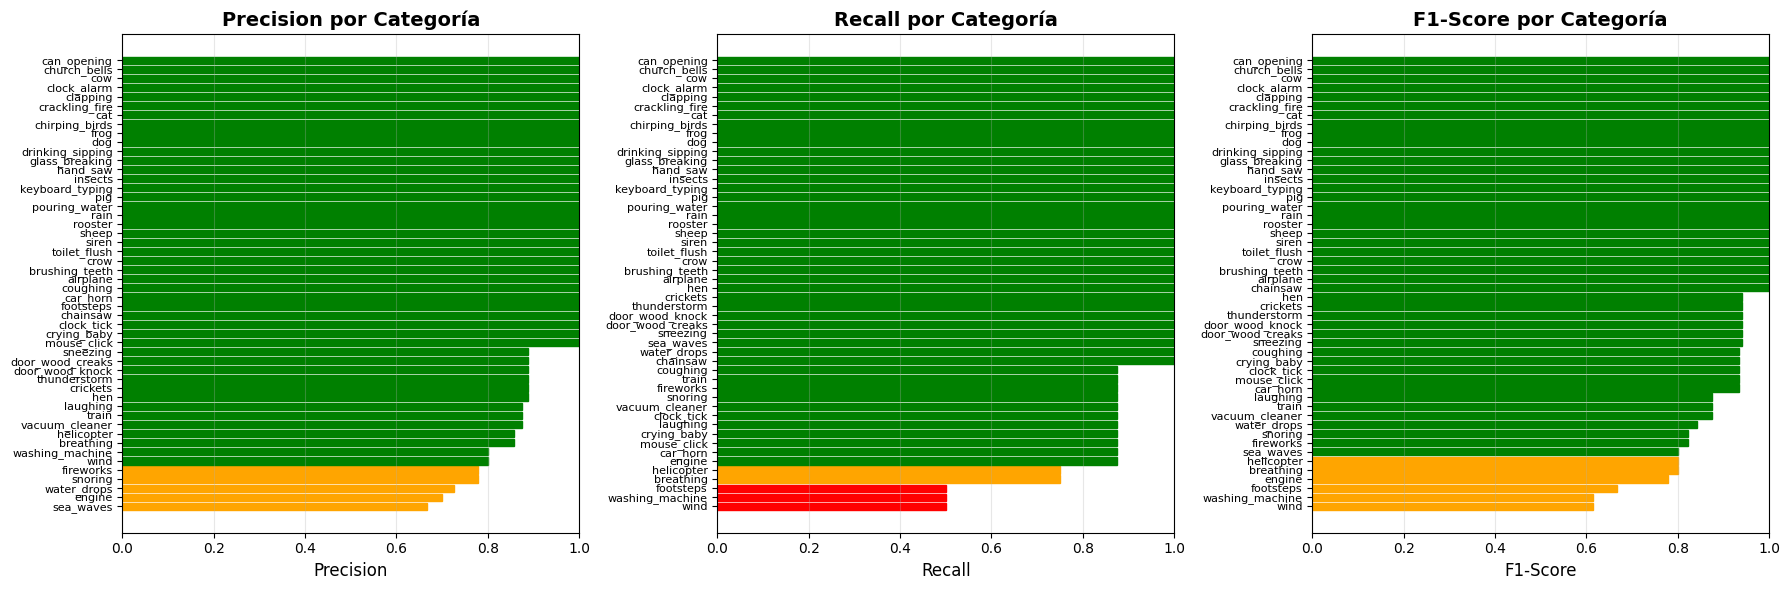

Gráfico guardado como: metricas_por_categoria.png


In [23]:
# Visualizar métricas por categoría
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

metrics_to_plot = ['Precision', 'Recall', 'F1-Score']
for idx, metric in enumerate(metrics_to_plot):
    ax = axes[idx]
    sorted_df = metrics_df.sort_values(metric, ascending=True)
    
    bars = ax.barh(range(len(sorted_df)), sorted_df[metric])
    ax.set_yticks(range(len(sorted_df)))
    ax.set_yticklabels(sorted_df['Categoría'], fontsize=8)
    ax.set_xlabel(metric, fontsize=12)
    ax.set_title(f'{metric} por Categoría', fontsize=14, fontweight='bold')
    ax.set_xlim(0, 1)
    ax.grid(axis='x', alpha=0.3)
    
    # Colorear las barras según el valor
    for bar, value in zip(bars, sorted_df[metric]):
        if value >= 0.8:
            bar.set_color('green')
        elif value >= 0.6:
            bar.set_color('orange')
        else:
            bar.set_color('red')

plt.tight_layout()
plt.savefig('metricas_por_categoria.png', dpi=150, bbox_inches='tight')
plt.show()

print("Gráfico guardado como: metricas_por_categoria.png")

In [24]:
# Calcular la matriz de confusión
cm = confusion_matrix(true_labels, pred_labels)

print("=== Matriz de Confusión ===")
print(f"Forma: {cm.shape}")
print(f"Total de predicciones: {cm.sum()}")

=== Matriz de Confusión ===
Forma: (50, 50)
Total de predicciones: 400


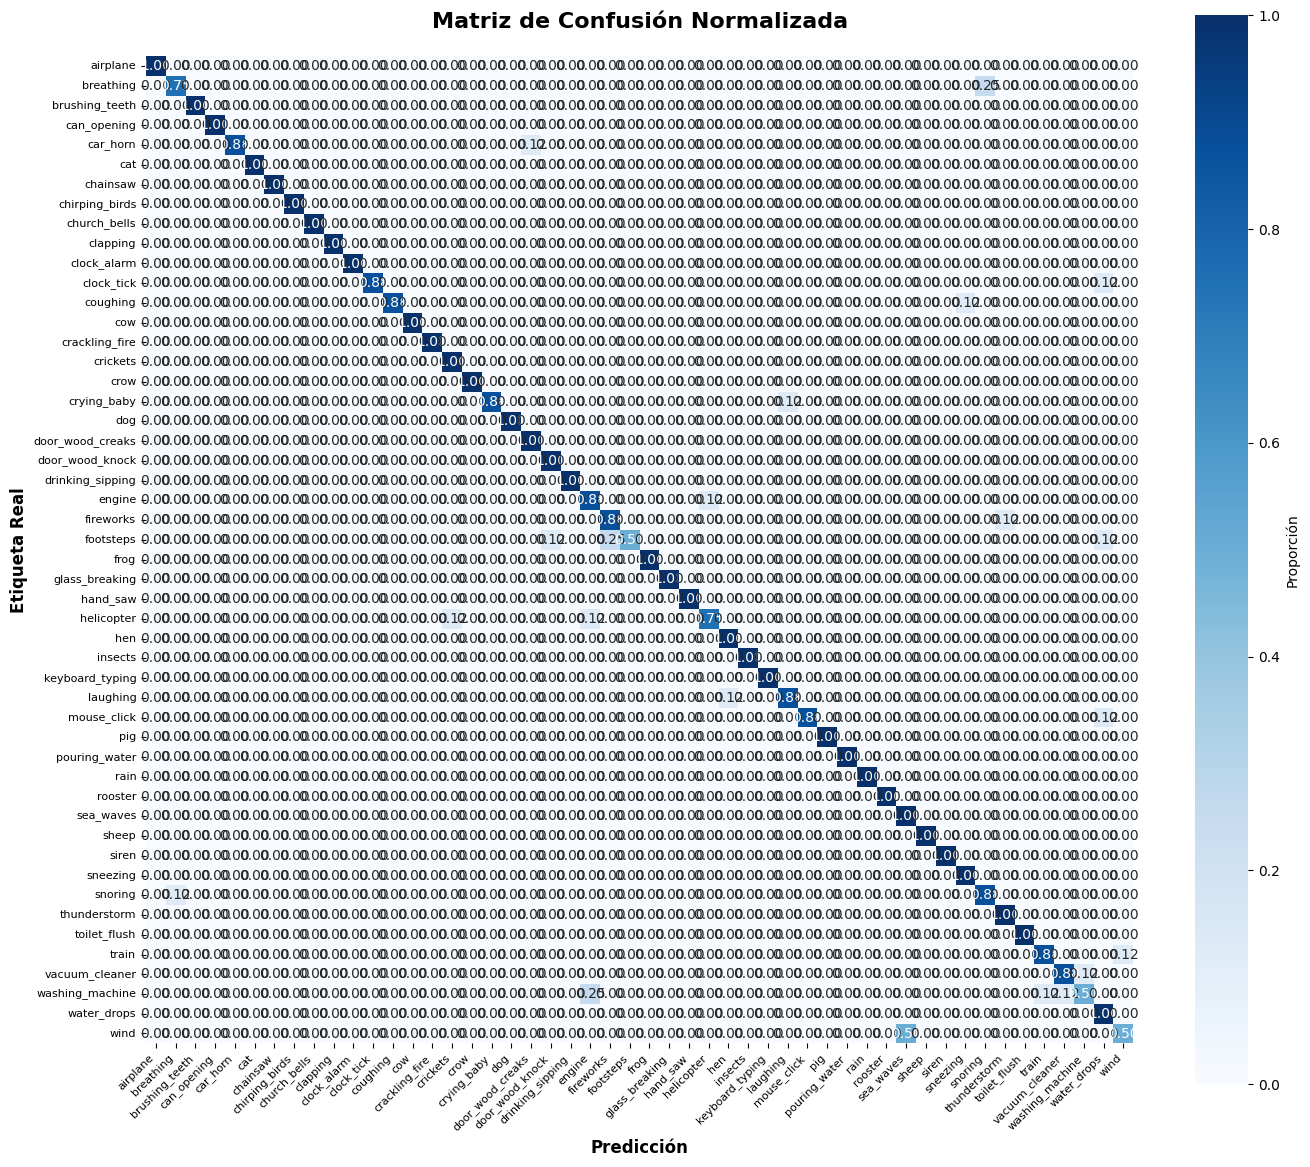

Matriz de confusión guardada como: matriz_confusion.png


In [25]:
# Visualizar la matriz de confusión
plt.figure(figsize=(14, 12))

# Normalizar la matriz de confusión
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

sns.heatmap(
    cm_normalized,
    annot=True,
    fmt='.2f',
    cmap='Blues',
    xticklabels=target_names,
    yticklabels=target_names,
    cbar_kws={'label': 'Proporción'},
    square=True
)

plt.title('Matriz de Confusión Normalizada', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Predicción', fontsize=12, fontweight='bold')
plt.ylabel('Etiqueta Real', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig('matriz_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

print("Matriz de confusión guardada como: matriz_confusion.png")

In [26]:
# Identificar las confusiones más comunes (errores fuera de la diagonal)
confusion_pairs = []

for i in range(len(labels)):
    for j in range(len(labels)):
        if i != j and cm[i, j] > 0:
            confusion_pairs.append({
                'Real': id2label[i],
                'Predicho': id2label[j],
                'Cantidad': cm[i, j],
                'Porcentaje': (cm[i, j] / cm[i].sum()) * 100
            })

confusion_df = pd.DataFrame(confusion_pairs)
confusion_df = confusion_df.sort_values('Cantidad', ascending=False)

print("=== Top 10 Confusiones Más Comunes ===")
print(confusion_df.head(10).to_string(index=False))

# Guardar análisis de confusiones
confusion_df.to_csv('analisis_confusiones.csv', index=False, encoding='utf-8')
print("\nAnálisis de confusiones guardado en: analisis_confusiones.csv")

=== Top 10 Confusiones Más Comunes ===
           Real        Predicho  Cantidad  Porcentaje
           wind       sea_waves         4        50.0
      footsteps       fireworks         2        25.0
washing_machine          engine         2        25.0
      breathing         snoring         2        25.0
    crying_baby        laughing         1        12.5
    mouse_click     water_drops         1        12.5
washing_machine  vacuum_cleaner         1        12.5
washing_machine           train         1        12.5
     clock_tick     water_drops         1        12.5
 vacuum_cleaner washing_machine         1        12.5

Análisis de confusiones guardado en: analisis_confusiones.csv


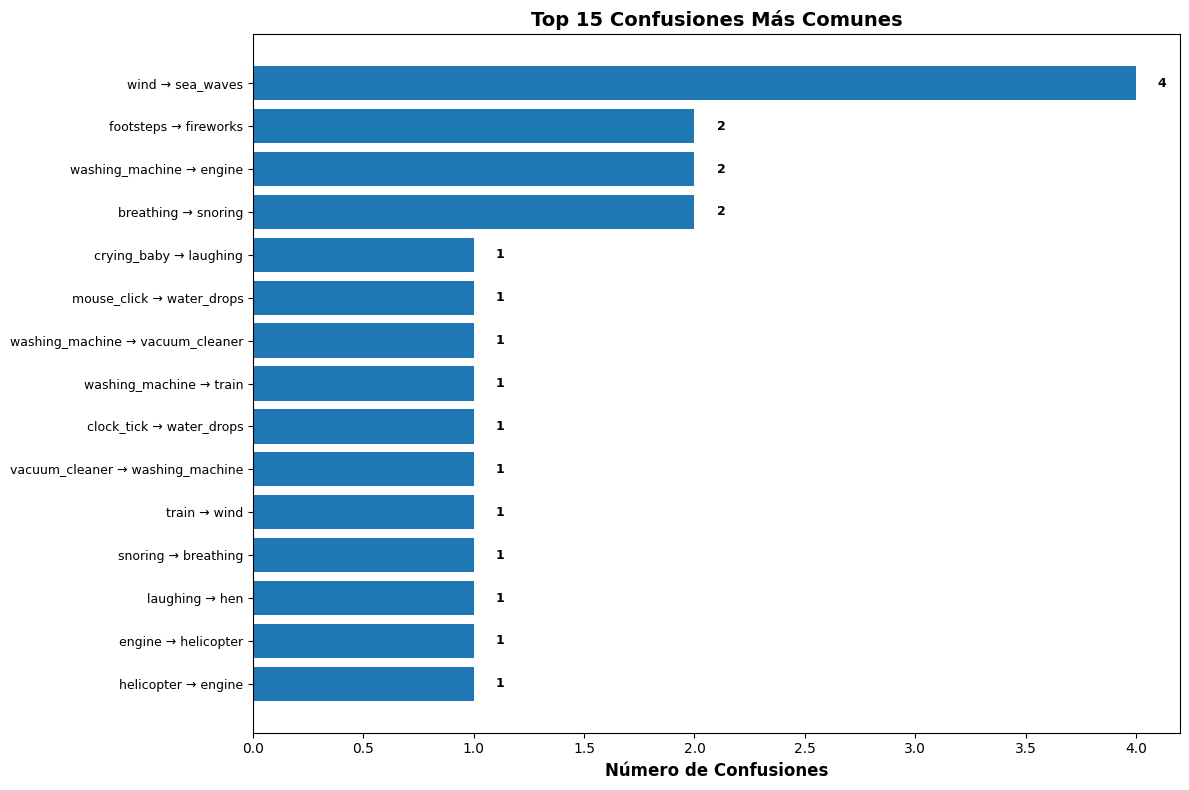

Gráfico guardado como: top_confusiones.png


In [27]:
# Visualizar las confusiones más comunes
if len(confusion_df) > 0:
    top_confusions = confusion_df.head(15)
    
    plt.figure(figsize=(12, 8))
    labels_confusion = [f"{row['Real']} → {row['Predicho']}" 
                       for _, row in top_confusions.iterrows()]
    
    bars = plt.barh(range(len(top_confusions)), top_confusions['Cantidad'])
    plt.yticks(range(len(top_confusions)), labels_confusion, fontsize=9)
    plt.xlabel('Número de Confusiones', fontsize=12, fontweight='bold')
    plt.title('Top 15 Confusiones Más Comunes', fontsize=14, fontweight='bold')
    plt.gca().invert_yaxis()
    
    # Añadir los valores en las barras
    for i, (bar, value) in enumerate(zip(bars, top_confusions['Cantidad'])):
        plt.text(value + 0.1, i, f'{int(value)}', 
                va='center', fontsize=9, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('top_confusiones.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print("Gráfico guardado como: top_confusiones.png")
else:
    print("¡El modelo no tiene confusiones! Todas las predicciones fueron correctas.")

In [29]:
print("="*60)
print("RESUMEN FINAL DEL PROYECTO")
print("="*60)

print("\n1. MODELO UTILIZADO")
print(f"   - Modelo base: {model_name}")
print(f"   - Épocas de fine-tuning: 2")
print(f"   - Dataset: ESC50 (fold1)")

print("\n2. MÉTRICAS GENERALES")
print(f"   - Accuracy:  {eval_results['eval_accuracy']:.4f} ({eval_results['eval_accuracy']*100:.2f}%)")
print(f"   - Precision: {eval_results['eval_precision']:.4f} ({eval_results['eval_precision']*100:.2f}%)")
print(f"   - Recall:    {eval_results['eval_recall']:.4f} ({eval_results['eval_recall']*100:.2f}%)")
print(f"   - F1-Score:  {eval_results['eval_f1']:.4f} ({eval_results['eval_f1']*100:.2f}%)")

print("\n3. CATEGORÍAS CON MEJOR RENDIMIENTO")
best_categories = metrics_df.nlargest(3, 'F1-Score')
for idx, row in best_categories.iterrows():
    print(f"   - {row['Categoría']}: F1={row['F1-Score']:.4f}")

print("\n4. CATEGORÍAS CON PEOR RENDIMIENTO")
worst_categories = metrics_df.nsmallest(3, 'F1-Score')
for idx, row in worst_categories.iterrows():
    print(f"   - {row['Categoría']}: F1={row['F1-Score']:.4f}")

print("\n5. ARCHIVOS GENERADOS")
print("   - ./ast_finetuned_final/ (modelo fine-tuned)")
print("   - espectrogramas_ejemplo.png")
print("   - metricas_por_categoria.png")
print("   - matriz_confusion.png")
print("   - top_confusiones.png")
print("   - classification_report.txt")
print("   - analisis_confusiones.csv")


RESUMEN FINAL DEL PROYECTO

1. MODELO UTILIZADO
   - Modelo base: MIT/ast-finetuned-audioset-10-10-0.4593
   - Épocas de fine-tuning: 2
   - Dataset: ESC50 (fold1)

2. MÉTRICAS GENERALES
   - Accuracy:  0.9325 (93.25%)
   - Precision: 0.9384 (93.84%)
   - Recall:    0.9325 (93.25%)
   - F1-Score:  0.9301 (93.01%)

3. CATEGORÍAS CON MEJOR RENDIMIENTO
   - airplane: F1=1.0000
   - crow: F1=1.0000
   - toilet_flush: F1=1.0000

4. CATEGORÍAS CON PEOR RENDIMIENTO
   - washing_machine: F1=0.6154
   - wind: F1=0.6154
   - footsteps: F1=0.6667

5. ARCHIVOS GENERADOS
   - ./ast_finetuned_final/ (modelo fine-tuned)
   - espectrogramas_ejemplo.png
   - metricas_por_categoria.png
   - matriz_confusion.png
   - top_confusiones.png
   - classification_report.txt
   - analisis_confusiones.csv
